# <b>Climate Impacts on Fish Stocks Analysis Capstone Project</b>
Author: Daisy Chu
<br>Date: 3/10/2026</br>
## Environmental Research Questions: 
- How does ocean temperature impact the number of fish landings in Portugal?
- How does ocean temperature and number of fish landings affect the national fish price?

Link to GitHub repository: [GitHub Repository](<https://github.com/daisychu12/pt-fisheries-climate-change>)

## Final Analysis and Visualizations

In this script, we'll run the final analysis and visualizations to observe the relationship between the top 5 species landed, as well as Northeast Atlantic sea surface temperature and national fish price. We'll do so using the data we cleaned from the data-cleaning script.

### Load Libraries and Processed Datasets

In [3]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(Hmisc)
library(caret)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.1
✔ readr     2.1.6     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


...

The following objects are masked from ‘package:dplyr’:

    src, summarize




The following objects are masked from ‘package:base’:

    format.pval, units




Loading required package: lattice




Attaching package: ‘caret’




The following object is masked from ‘package:purrr’:

    lift




In [4]:
# Set working dir to processed data folder
setwd("../data/processed_data")
list.files()

[1] "atl_cod.csv"            "bl_jack.csv"            "clim_and_cost.csv"     
[4] "common_oct.csv"         "horse_mack.csv"         "pt_annual_landings.csv"
[7] "README.md"              "sardine.csv"            "top_5_landings.csv"

In [5]:
# Load datasets
atl_cod <- read.csv("atl_cod.csv")
bl_jack <- read.csv("bl_jack.csv")
common_oct <- read.csv("common_oct.csv")
horse_mack <- read.csv("horse_mack.csv")
top_5_landings <- read.csv("top_5_landings.csv")
pt_annual_landings <- read.csv("pt_annual_landings.csv")
clim_and_cost <- read.csv("clim_and_cost.csv")
sardine <- read.csv("sardine.csv")

In [6]:
# Create a dataframe for total landings of all species and annual fish cost
landings_price <- pt_annual_landings %>%
  group_by(year) %>%
  summarise(sum_landings = sum(total_landings)) %>%
  left_join(clim_and_cost, by = "year") %>%
  select(year, sum_landings, price) %>%
  drop_na()

head(landings_price)

year,sum_landings,price
<int>,<dbl>,<dbl>
2011,450202.7,1.67
2012,384841.8,1.81
2013,378927.3,1.70
2014,326861.0,2.02
2015,327649.9,1.81
2016,346359.9,2.10


### Correlation Analysis on Fish Landings and Cost and Temperature

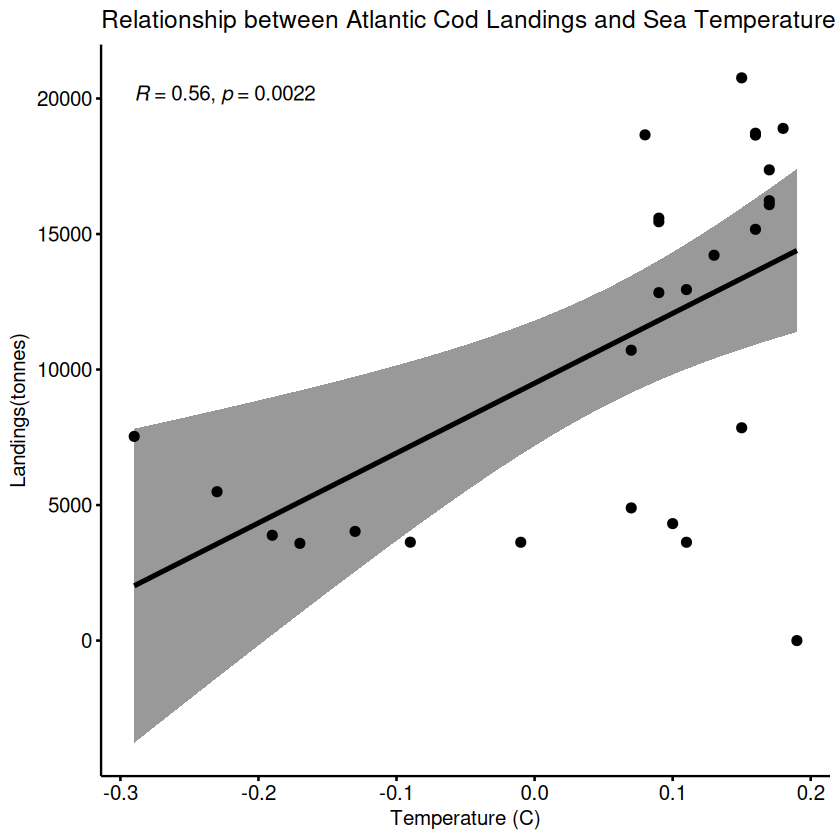

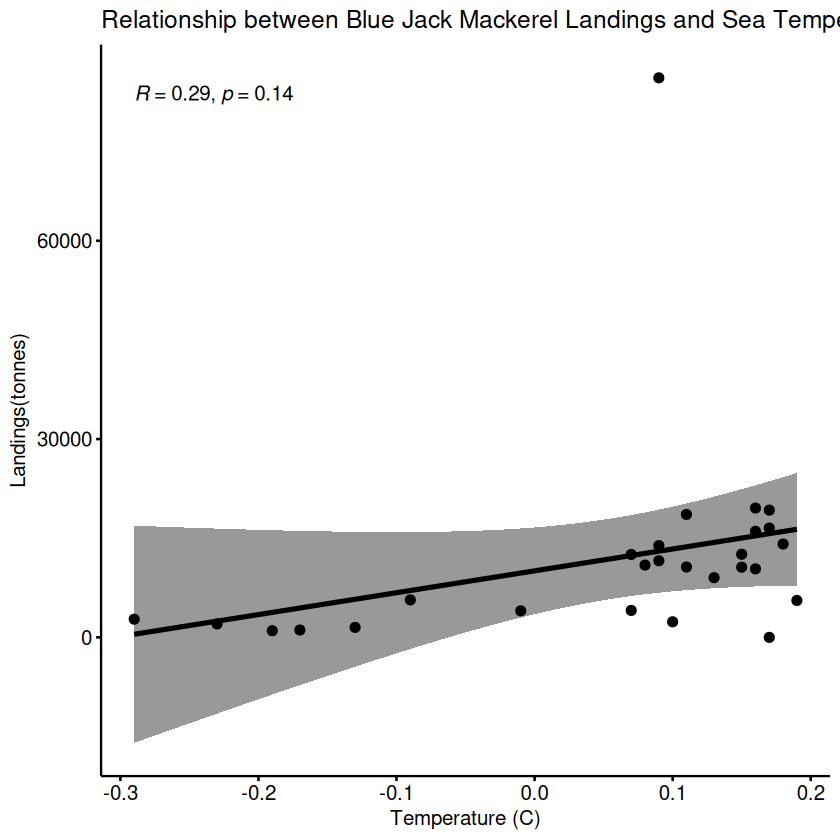

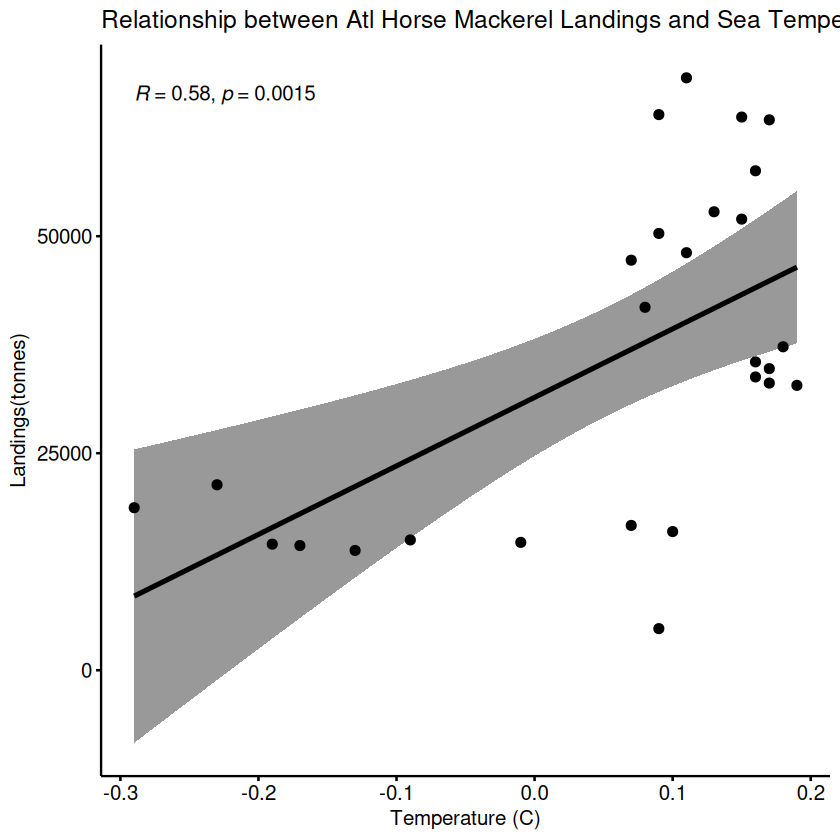

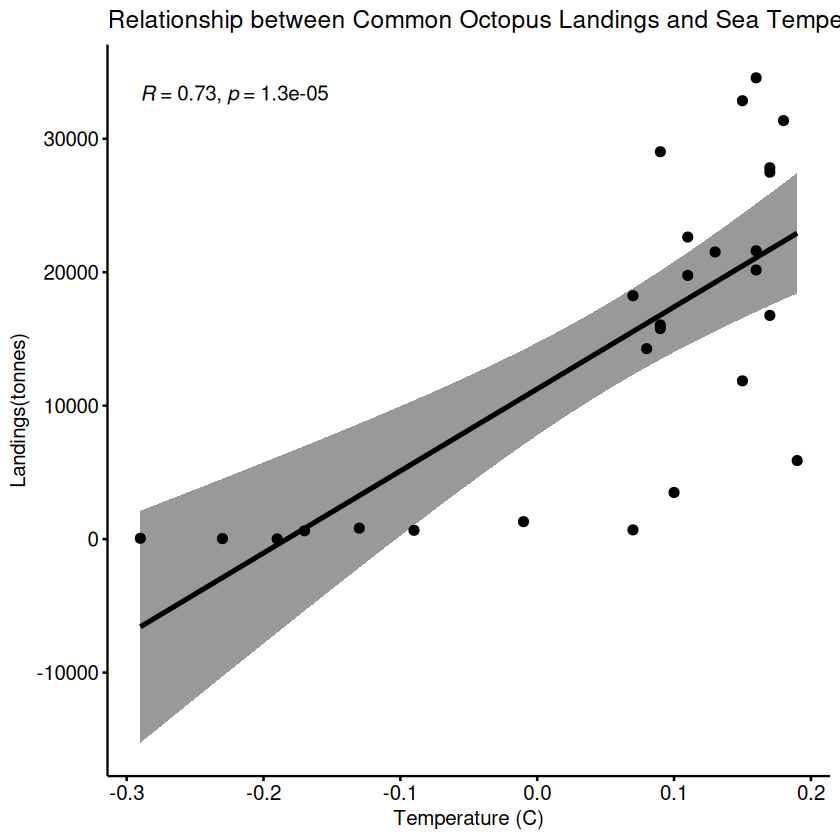

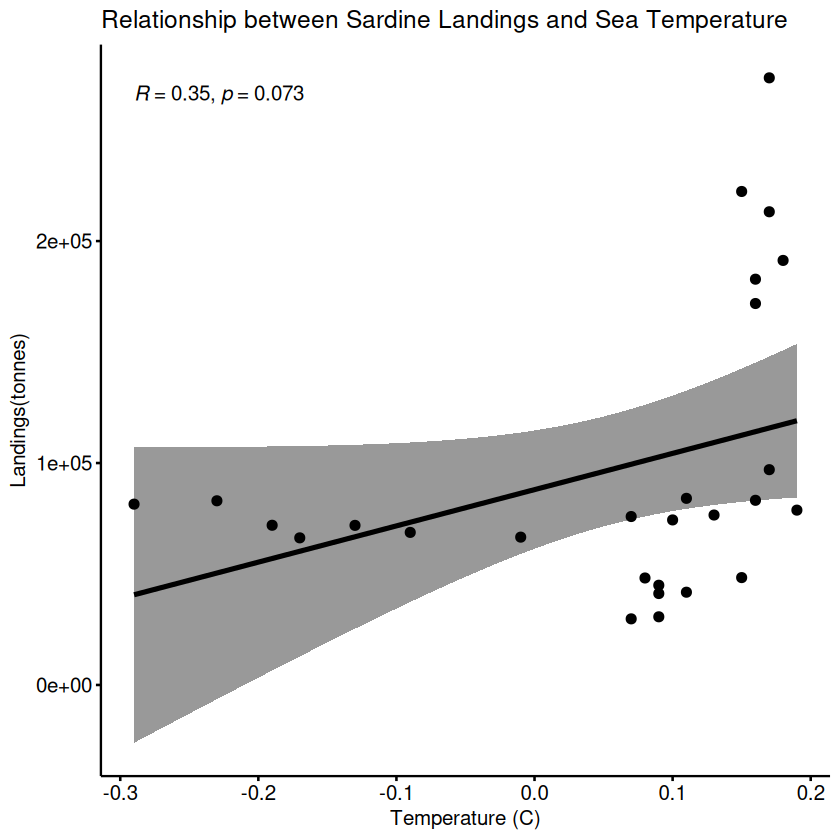

In [7]:
# Conduct and Plot Correlation Analysis on Atlantic Cod
# Use ggscatter
ggscatter(atl_cod, x = "max_temp", y = "total_landings", 
  add = "reg.line", conf.int = TRUE, 
  # set correlation method to Pearson
  cor.coef = TRUE, cor.method = "pearson",
  title = "Relationship between Atlantic Cod Landings and Sea Temperature",
  xlab = "Temperature (C)", ylab = "Landings(tonnes)")

# Conduct and Plot Correlation Analysis on Blue Jack Mackerel
# Use ggscatter
ggscatter(bl_jack, x = "max_temp", y = "total_landings", 
  add = "reg.line", conf.int = TRUE, 
  # set correlation method to Pearson
  cor.coef = TRUE, cor.method = "pearson",
  title = "Relationship between Blue Jack Mackerel Landings and Sea Temperature",
  xlab = "Temperature (C)", ylab = "Landings(tonnes)")

# Conduct and Plot Correlation Analysis on Atlantic Horse Mackerel
# Use ggscatter
ggscatter(horse_mack, x = "max_temp", y = "total_landings", 
  add = "reg.line", conf.int = TRUE, 
  # set correlation method to Pearson
  cor.coef = TRUE, cor.method = "pearson",
  title = "Relationship between Atl Horse Mackerel Landings and Sea Temperature",
  xlab = "Temperature (C)", ylab = "Landings(tonnes)")

# Conduct and Plot Correlation Analysis on Common Octopus
# Use ggscatter
ggscatter(common_oct, x = "max_temp", y = "total_landings", 
  add = "reg.line", conf.int = TRUE, 
  # set correlation method to Pearson
  cor.coef = TRUE, cor.method = "pearson",
  title = "Relationship between Common Octopus Landings and Sea Temperature",
  xlab = "Temperature (C)", ylab = "Landings(tonnes)")

# Conduct and Plot Correlation Analysis on Sardine
# Use ggscatter
ggscatter(sardine, x = "max_temp", y = "total_landings", 
  add = "reg.line", conf.int = TRUE, 
  # set correlation method to Pearson
  cor.coef = TRUE, cor.method = "pearson",
  title = "Relationship between Sardine Landings and Sea Temperature",
  xlab = "Temperature (C)", ylab = "Landings(tonnes)")

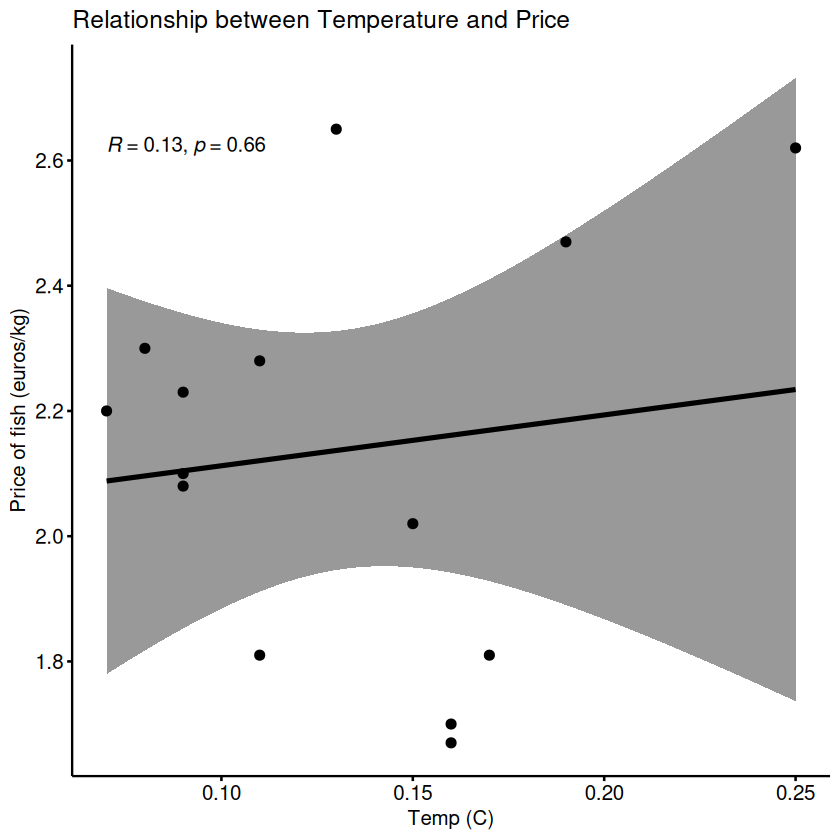

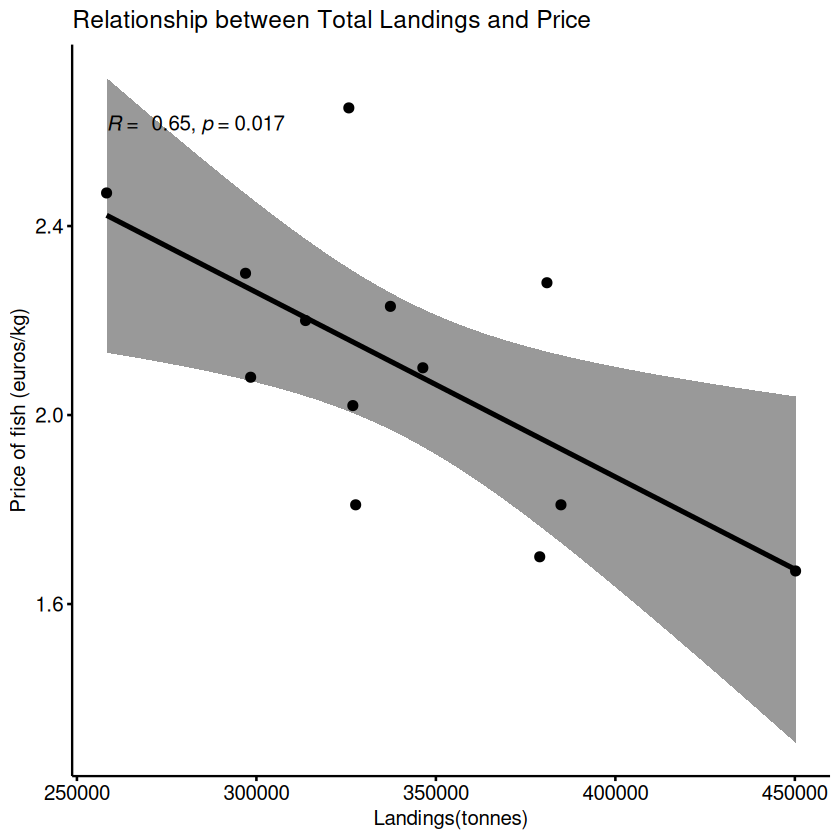

In [8]:
# Conduct and Plot Correlation Analysis on Climate and Cost
ggscatter(clim_and_cost, x = "max_temp", y = "price", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Relationship between Temperature and Price",
          xlab = "Temp (C)", ylab = "Price of fish (euros/kg)")

# Conduct and Plot Correlation Analysis on Landings and Cost
ggscatter(landings_price, x = "sum_landings", y = "price", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          title = "Relationship between Total Landings and Price",
          xlab = "Landings(tonnes)", ylab = "Price of fish (euros/kg)")

### Regression Analysis on Fish Landings and Cost and Temperature


Call:
lm(formula = total_landings ~ poly(max_temp, 2), data = atl_cod)

Residuals:
   Min     1Q Median     3Q    Max 
-16282  -1322   1046   2788   8358 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)           10917       1028  10.616 1.51e-10 ***
poly(max_temp, 2)1    18468       5344   3.456  0.00205 ** 
poly(max_temp, 2)2     7061       5344   1.321  0.19884    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5344 on 24 degrees of freedom
Multiple R-squared:  0.3632,	Adjusted R-squared:  0.3102 
F-statistic: 6.845 on 2 and 24 DF,  p-value: 0.004444


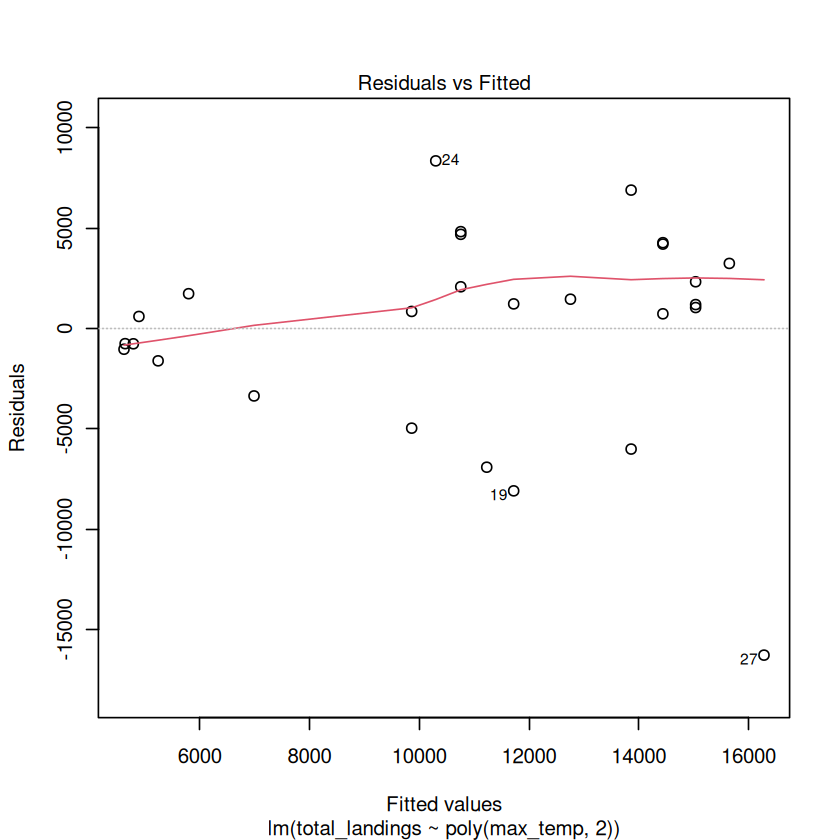

In [9]:
# Regression Analysis on Temperature and Atlantic Cod Landings
atl_cod_mod <- lm(total_landings ~ poly(max_temp, 2), data=atl_cod)

# Print summary of results
summary(atl_cod_mod)

# Plot Residuals vs Fitted
plot(atl_cod_mod, 1)

The relationship between maximum sea surface temperature and atlantic cod landings is significant with a p-value of 0.004. 36% of the variance in total landings is explained by sea surface temperature.


Call:
lm(formula = total_landings ~ poly(max_temp, 2), data = bl_jack)

Residuals:
   Min     1Q Median     3Q    Max 
-14260  -4716  -2751   1451  70302 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)           11892       3001   3.963 0.000578 ***
poly(max_temp, 2)1    23707      15592   1.520 0.141465    
poly(max_temp, 2)2    -8706      15592  -0.558 0.581764    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15590 on 24 degrees of freedom
Multiple R-squared:  0.09854,	Adjusted R-squared:  0.02342 
F-statistic: 1.312 on 2 and 24 DF,  p-value: 0.288


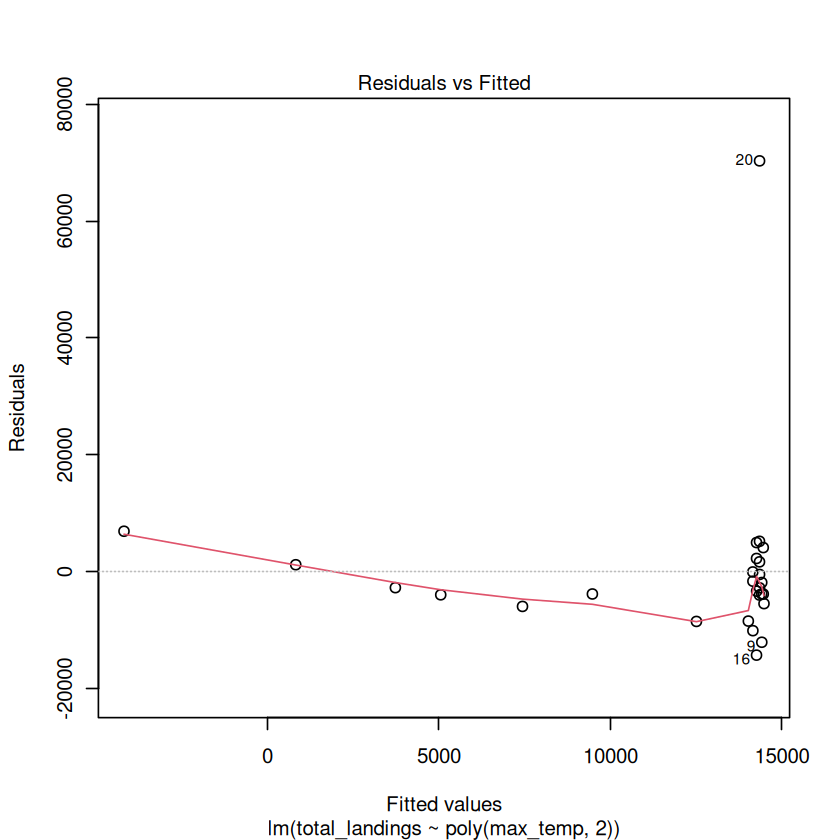

In [10]:
# Regression Analysis on Temperature and Blue Jack Mackerel Landings
bl_jack_mod <- lm(total_landings ~ poly(max_temp, 2), data=bl_jack)

# Print summary of results
summary(bl_jack_mod)

# Plot Residuals vs Fitted
plot(bl_jack_mod, 1)

The relationship between maximum sea surface temperature and blue jack mackerel landings is not significant with a p-value of 0.29. Only 9% of the variance in total landings is explained by sea surface temperature.


Call:
lm(formula = max_temp ~ poly(total_landings, 2), data = horse_mack)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.27350 -0.04697  0.01098  0.08116  0.23708 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)   
(Intercept)               0.05519    0.02207   2.500  0.01964 * 
poly(total_landings, 2)1  0.41680    0.11468   3.634  0.00132 **
poly(total_landings, 2)2 -0.15527    0.11468  -1.354  0.18839   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1147 on 24 degrees of freedom
Multiple R-squared:  0.3853,	Adjusted R-squared:  0.334 
F-statistic: 7.521 on 2 and 24 DF,  p-value: 0.002912


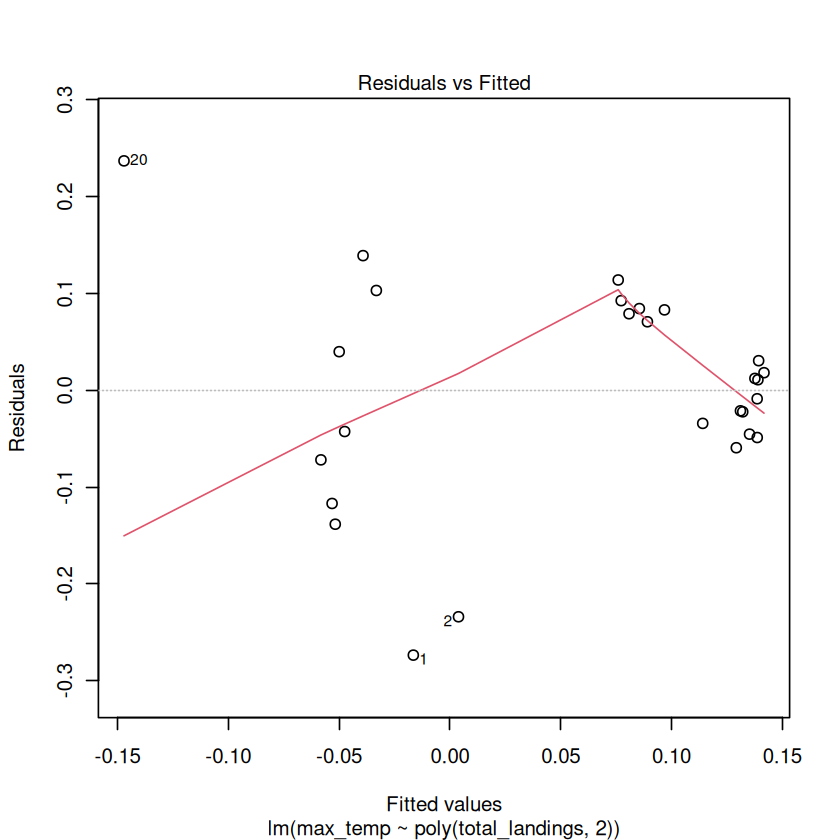

In [11]:
# Regression Analysis on Temperature and Atlantic Horse Mackerel Landings
horse_mack_mod <- lm(max_temp ~ poly(total_landings, 2), data=horse_mack)

# Print summary of results
summary(horse_mack_mod)

# Plot Residuals vs Fitted
plot(horse_mack_mod, 1)

The relationship between maximum sea surface temperature and atlantic horse mackerel landings is significant with a p-value of 0.003. 39% of the variance in total landings is explained by sea surface temperature.


Call:
lm(formula = total_landings ~ poly(max_temp, 2), data = common_oct)

Residuals:
     Min       1Q   Median       3Q      Max 
-20140.5  -2077.4    631.1   4059.3  13980.5 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)           14643       1532   9.556 1.18e-09 ***
poly(max_temp, 2)1    44040       7962   5.531 1.09e-05 ***
poly(max_temp, 2)2    11571       7962   1.453    0.159    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7962 on 24 degrees of freedom
Multiple R-squared:  0.5768,	Adjusted R-squared:  0.5415 
F-statistic: 16.35 on 2 and 24 DF,  p-value: 3.303e-05


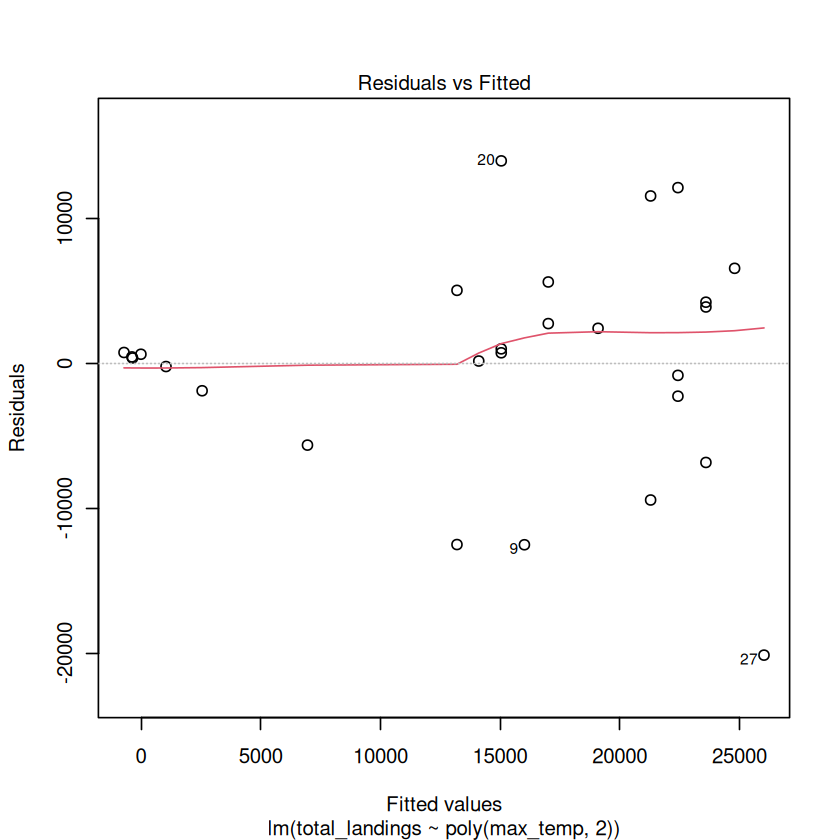

In [12]:
# Regression Analysis on Temperature and Common Octopus Landings
common_oct_mod <- lm(total_landings ~ poly(max_temp, 2), data=common_oct)

# Print summary of results
summary(common_oct_mod)

# Plot Residuals vs Fitted
plot(common_oct_mod, 1)

The relationship between maximum sea surface temperature and common octopus landings is significant with a p-value of 3.303e-05. 58% of the variance in total landings is explained by sea surface temperature.


Call:
lm(formula = total_landings ~ poly(max_temp, 2), data = sardine)

Residuals:
   Min     1Q Median     3Q    Max 
-83362 -41305  -8016  37503 131311 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)           97033      10511   9.231 2.29e-09 ***
poly(max_temp, 2)1   117052      54619   2.143  0.04245 *  
poly(max_temp, 2)2   160901      54619   2.946  0.00705 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 54620 on 24 degrees of freedom
Multiple R-squared:  0.3561,	Adjusted R-squared:  0.3024 
F-statistic: 6.636 on 2 and 24 DF,  p-value: 0.005082


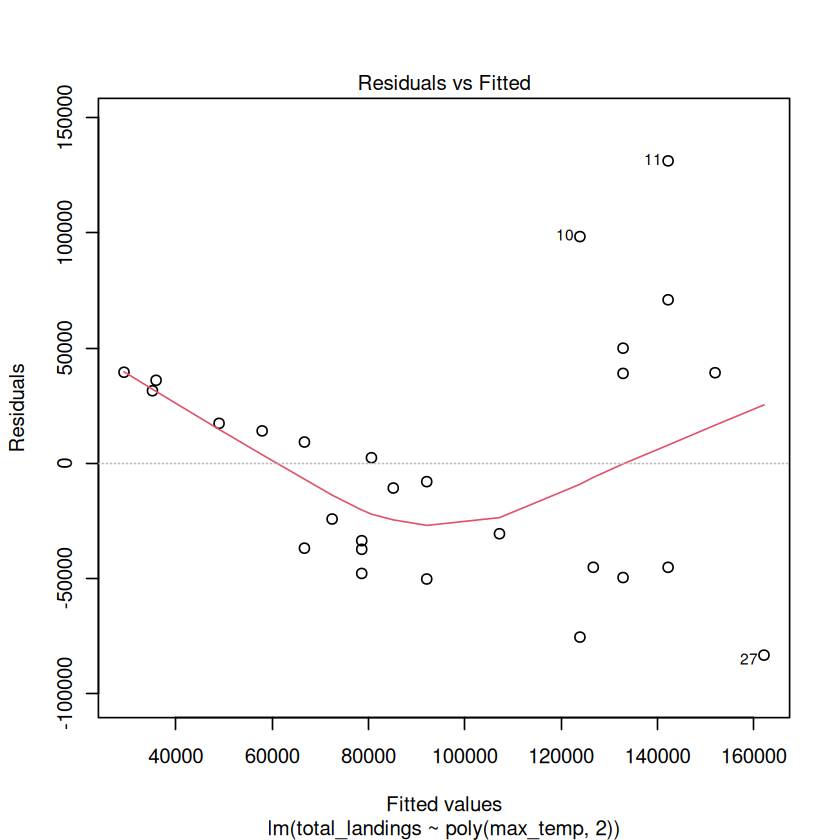

In [13]:
# Regression Analysis on Temperature and Sardine Landings
sardine_mod <- lm(total_landings ~ poly(max_temp, 2), data=sardine)

# Print summary of results
summary(sardine_mod)

# Plot Residuals vs Fitted
plot(sardine_mod, 1)

The relationship between maximum sea surface temperature and sardine landings is significant with a p-value of 0.005. 36% of the variance in total landings is explained by sea surface temperature.


Call:
lm(formula = price ~ poly(max_temp, 2), data = clim_and_cost)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33991 -0.19388 -0.03150  0.07029  0.64201 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)         2.13857    0.07831  27.309 1.85e-11 ***
poly(max_temp, 2)1  0.14844    0.29301   0.507   0.6224    
poly(max_temp, 2)2  0.58459    0.29301   1.995   0.0714 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.293 on 11 degrees of freedom
Multiple R-squared:  0.2781,	Adjusted R-squared:  0.1468 
F-statistic: 2.119 on 2 and 11 DF,  p-value: 0.1666


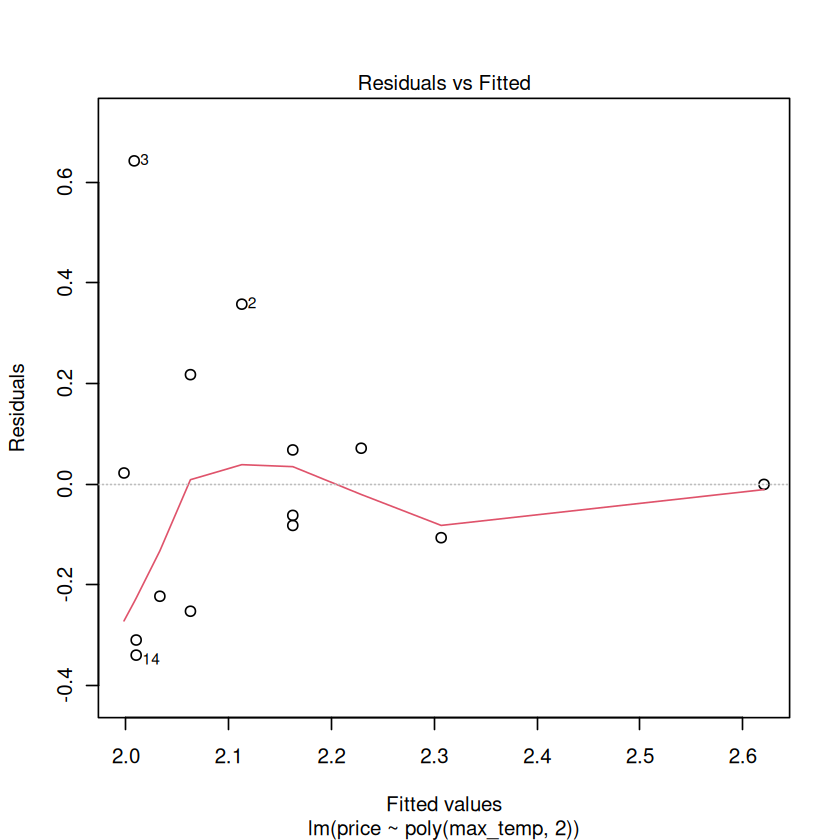

In [14]:
# Regression Analysis on Temperature and Fish Cost
clim_cost_mod <- lm(price ~ poly(max_temp, 2), data=clim_and_cost)

# Print summary of results
summary(clim_cost_mod)

# Plot Residuals vs Fitted
plot(clim_cost_mod, 1)

The relationship between maximum sea surface temperature and annual price of fish is not significant with a p-value of 0.17. 28% of the variance in price is explained by sea surface temperature.


Call:
lm(formula = price ~ sum_landings, data = landings_price)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.34164 -0.13472 -0.00287  0.04729  0.49092 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   3.432e+00  4.794e-01   7.158 1.85e-05 ***
sum_landings -3.907e-06  1.395e-06  -2.801   0.0172 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.237 on 11 degrees of freedom
Multiple R-squared:  0.4163,	Adjusted R-squared:  0.3632 
F-statistic: 7.846 on 1 and 11 DF,  p-value: 0.01724


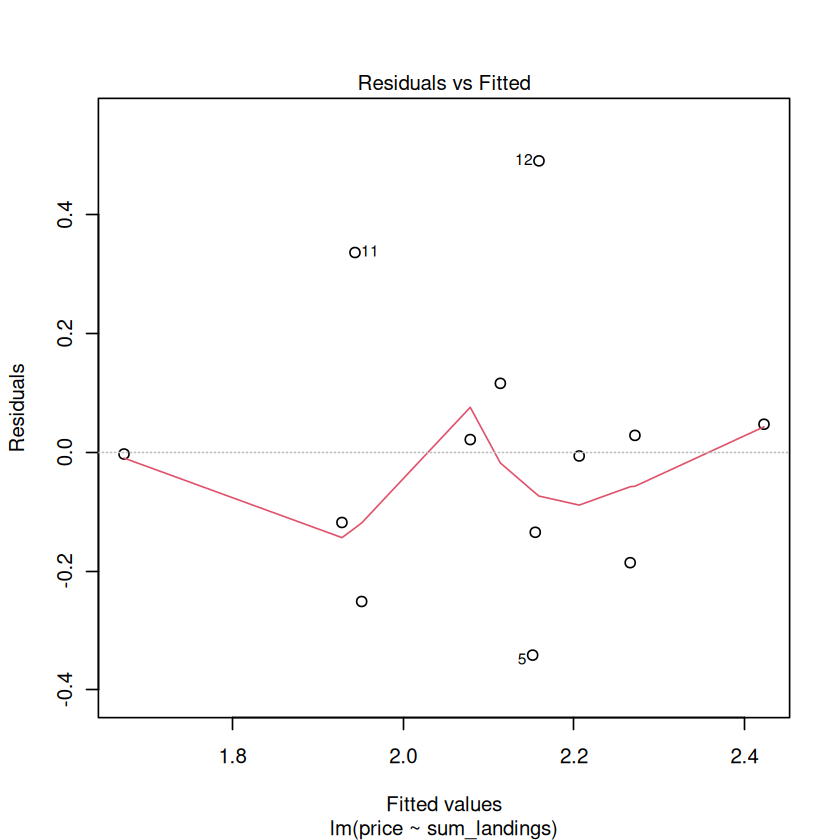

In [15]:
# Regression Analysis on Total Fish Landings and Fish Cost
landings_price_mod <- lm(price ~ sum_landings, data=landings_price)

# Print summary of results
summary(landings_price_mod)

# Plot Residuals vs Fitted
plot(landings_price_mod, 1)

The relationship between total annual fish landings and annual price of fish is significant with a p-value of 0.02. 42% of the variance in price is explained by total annual landings.

## Ethical Considerations
- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

## Acknowledging Limitations
- Limited scope: Only includes data available and may not capture the entire spectrum of fish landings data due to confidential reports from Portgual on fish landings of certain species
- Data quality: Possible measurement errors or missing values.
- Under-generalization: There could be multiple factors that come into play that impact fish landing numbers, however in this analysis, I only focus on maximum sea surface temperature.

## Results for Non-Technical Audience
Impact of landings and vulnerability to climate change is species dependent, but 4 out of the 5 species studied in this analysis show a significant relationship with rising maximum sea temperatures. Although there is no significant relationship between ocean temperature and annual price of fish, the significant relationship between annual number of landings and price of fish suggests that changes in landings due to a changing climate can impact fish price as well. 

## Instructions for Reproducing Project
1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed (`dplyr`, `ggplot2`, `tidyverse`, `caret`, `ggpubr`, `Hmisc`).
3. Open and run the provided Jupyter notebooks (`data-cleaning.ipynb` and `data-analysis-and-results.ipynb`).